# 09 · Assemble a TS from a core arrangement + fresh fragments

Notebook `05` transferred a **known geometry** onto a new molecule. Often you don't *have* one — you know the
reacting core's **arrangement**: a handful of distances/angles (internals), or explicit target coordinates —
and you want to hang real catalyst / substrate / co-reactant fragments (written as **SMILES**, possibly
`.`-disconnected) around it. `rxembed` builds the whole TS from that.

The pieces, all on the one chain:

- **SMARTS picks the atoms** — your two RDKit lines. The API is index-driven on purpose (DESIGN §10): *you*
  resolve SMARTS, so a symmetric core can never silently flip.
- **`fix=` states the core** — `{(i, j): d, (i, j, k): θ}` for internals, or `{i: (x, y, z)}` for explicit
  coordinates. `fix` is rigid: numbers are pulled to target, coordinates are Kabsch-grafted back to 0.000 Å.
- **Disconnected fragments are auto-tethered** at van-der-Waals contact, so nothing the core doesn't pin
  drifts off to infinity.

No `coordMap`, no per-reaction bond surgery — a core is just a set of indices biased into the ETKDG **bounds
matrix** and grafted back exactly, so it composes with the metal / NCI machinery unchanged.

In [1]:
import tempfile

import numpy as np
import rxembed as rx
import xyzrender
from rdkit import Chem, RDLogger

from rxembed import geometry as geom

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")

## 1 · Internals — state the core as numbers

No reference geometry at all. An SN2 core, straight from chemical intuition: F⁻ attacks the carbon at a
forming distance of **2.0 Å**, the C–Cl bond is half-broken at **2.3 Å**, and the three are **collinear
(180°)**. The two reactants are just two `.`-disconnected SMILES fragments. `fix={…numbers…}` biases the
bounds matrix toward that core; `.mc()` searches the propyl periphery around it. We confirm the core landed
with `.measure()` (a `fix` number is a *pull*, not a hard snap — always verify).

rxembed | resolve: fix d(F0,C3)->1.98-2.02A; fix d(C3,Cl4)->2.28-2.32A; fix angle(F0,C3,Cl4)->178.0-182.0deg
rxembed | embed: 4 seeds (12 atoms, 2 fragments, 3 constraints)
rxembed | mc: 3 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +2 (openconf 'ensemble', pose-constrained around seeds; total 6)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0] | window=250 -> all within window
rxembed | prune[rmsd]: 6 -> 2  (merged 4 near-duplicates; see .duplicates())


2 conformers | d(F,C) 2.060 A | d(C,Cl) 2.255 A | angle 178.0 deg


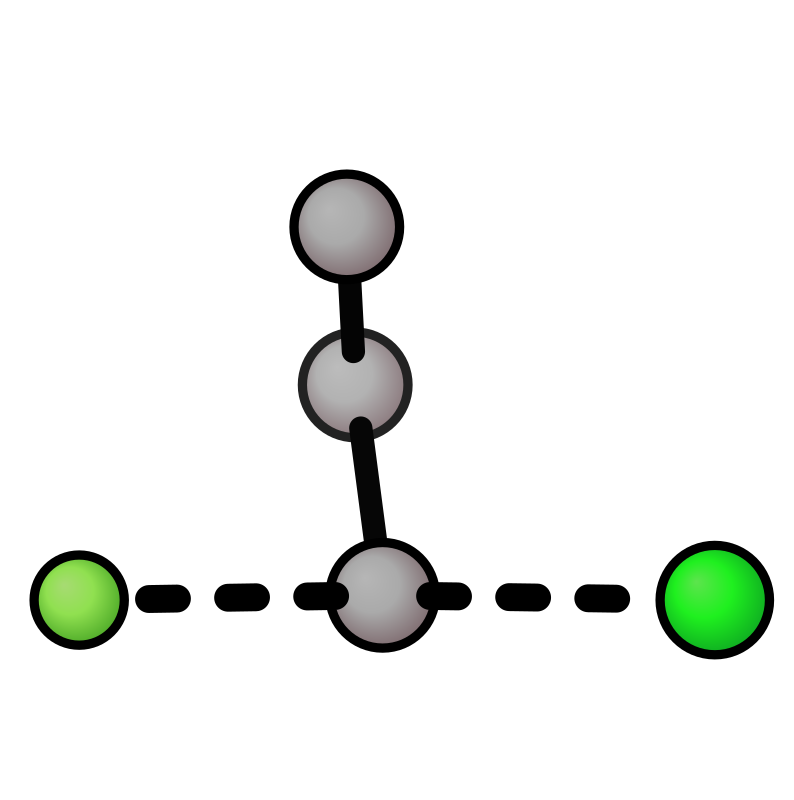

In [2]:
mol = Chem.AddHs(Chem.MolFromSmiles("[F-].CCCCl"))  # nucleophile + 1-chloropropane, two fragments
# your two RDKit lines: SMARTS -> the (F, C, Cl) atom indices (index-driven, so nothing can silently flip)
f, c, cl = (mol.GetSubstructMatch(Chem.MolFromSmarts(s))[0] for s in ("[F-]", "[CH2]Cl", "[Cl-,Cl]"))

ens = rx.embed(mol, fix={(f, c): 2.0, (c, cl): 2.3, (f, c, cl): 180.0}).mc().prune()

print(
    f"{len(ens)} conformers | d(F,C) {ens.measure((f, c))['mean']:.3f} A "
    f"| d(C,Cl) {ens.measure((c, cl))['mean']:.3f} A | angle {ens.measure((f, c, cl))['mean']:.1f} deg"
)
for cid in ens.ids:
    geom.check(ens.mol, cid, frozen=[f, c, cl]).assert_ok()  # forming/breaking pair exempted from clash

xyzrender.render(  # forming F...C and breaking C...Cl drawn dashed
    ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, ts_bonds=[(f + 1, c + 1), (c + 1, cl + 1)]
)

## 2 · Cartesian — state the core as explicit coordinates

When you already have **target positions** — lifted off a model TS, or laid out by hand — `fix={i: (x, y, z)}`
places exactly those atoms and searches everything else. Here a benzyl chloride: the (F, C, Cl) core is
pinned to a linear layout and Kabsch-grafted back, so the measured distances match the input to the
milli-ångström. The overlay (aligned on the core) shows it held rigid while the aryl ring fans out.

rxembed | resolve: graft F0, C7, Cl8
rxembed | embed: 1 seeds (16 atoms, 2 fragments, 3 constraints)
rxembed | mc: 3 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 2)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0] | window=250 -> all within window
rxembed | prune[rmsd]: 2 -> 2  (merged 0 near-duplicates; see .duplicates())


2 conformers | grafted d(F,C) 2.000 A | d(C,Cl) 2.300 A | d(F,Cl) 4.300 A


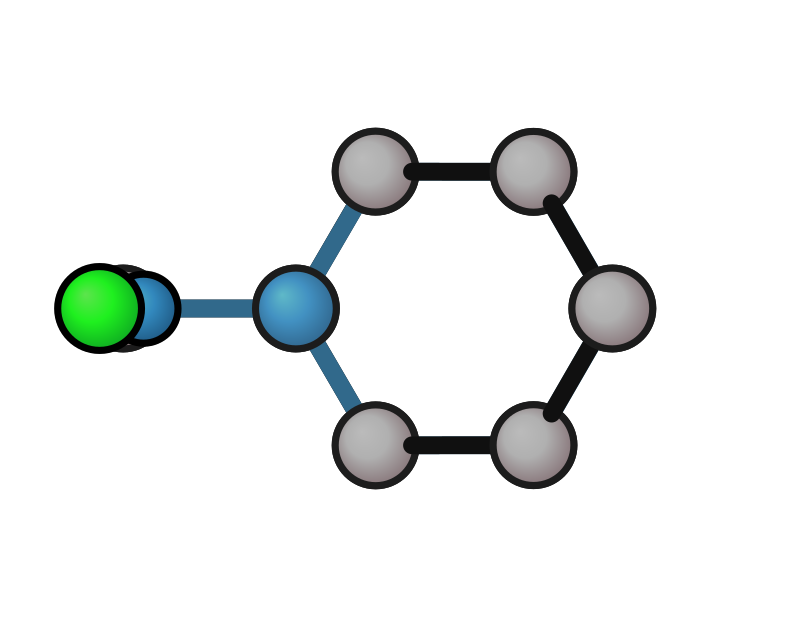

In [3]:
mol = Chem.AddHs(Chem.MolFromSmiles("[F-].c1ccccc1CCl"))  # F- + benzyl chloride
f, c, cl = (mol.GetSubstructMatch(Chem.MolFromSmarts(s))[0] for s in ("[F-]", "[CH2]Cl", "[Cl-,Cl]"))
core = {f: (0.0, 0.0, 0.0), c: (2.0, 0.0, 0.0), cl: (4.3, 0.0, 0.0)}  # a linear F...C...Cl, explicit xyz

ens = rx.embed(mol, fix=core).mc().prune()
print(
    f"{len(ens)} conformers | grafted d(F,C) {ens.measure((f, c))['mean']:.3f} A "
    f"| d(C,Cl) {ens.measure((c, cl))['mean']:.3f} A | d(F,Cl) {ens.measure((f, cl))['mean']:.3f} A"
)
for cid in ens.ids:
    geom.check(ens.mol, cid, frozen=[f, c, cl]).assert_ok()

overlay = ens.align().dump(tempfile.mktemp(suffix=".xyz"))  # align on the constrained core (the default)
xyzrender.render(xyzrender.load(overlay, ensemble=True, ensemble_color="spectral"), no_hy=True)

## 3 · A third fragment — the core spans all of them

A core is just a set of indices, so it can pin a key atom in **each** of three (or more) `.`-joined fragments
at once. Here a base (F⁻), the substrate (an alkyl chloride), and an explicit **third fragment** — a water
microsolvating the departing chloride. Every core atom is placed by coordinate; the water is positioned by
its oxygen next to the leaving Cl. Fragments (and parts of fragments) the core does **not** pin are tethered
at vdW contact automatically, so the assembly holds together instead of dissociating.

rxembed | resolve: graft F0, C4, Cl5, O6
rxembed | embed: 27 seeds (18 atoms, 3 fragments, 6 constraints)
rxembed | mc: 4 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +26 (openconf 'ensemble', pose-constrained around seeds; total 53)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.7] | window=250 -> all within window
rxembed | prune[rmsd]: 53 -> 10  (merged 43 near-duplicates; see .duplicates())


10 conformers over 3 fragments | d(F,C) 2.000 A | d(Cl,O) 2.220 A


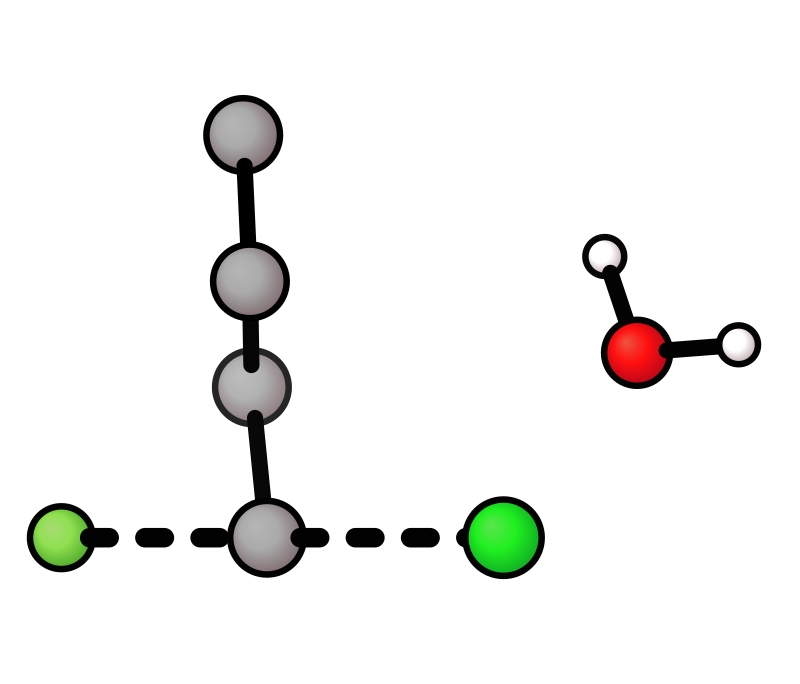

In [4]:
mol = Chem.AddHs(Chem.MolFromSmiles("[F-].CCCCCl.O"))  # base . substrate . water — three fragments
f, c, cl, o = (mol.GetSubstructMatch(Chem.MolFromSmarts(s))[0] for s in ("[F-]", "[CH2]Cl", "[Cl-,Cl]", "[OX2H2]"))
core = {f: (0.0, 0.0, 0.0), c: (2.0, 0.0, 0.0), cl: (4.3, 0.0, 0.0), o: (5.6, 1.8, 0.0)}  # O H-bonds the Cl

ens = rx.embed(mol, fix=core).mc().prune()
print(
    f"{len(ens)} conformers over {len(Chem.GetMolFrags(mol))} fragments "
    f"| d(F,C) {ens.measure((f, c))['mean']:.3f} A | d(Cl,O) {ens.measure((cl, o))['mean']:.3f} A"
)
for cid in ens.ids:
    geom.check(ens.mol, cid, frozen=[f, c, cl, o]).assert_ok()

xyzrender.render(
    ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, ts_bonds=[(f + 1, c + 1), (c + 1, cl + 1)]
)

## 4 · The payoff — a reactive-complex / TS-guess generator

This is where the one chain does something **no general tool does in a single call.** Every conformer
generator — RDKit/ETKDG, CREST, OpenBabel, Balloon — searches *one connected molecule*; hand it `A.B` and the
fragments drift apart or interpenetrate, because nothing holds an *inter-fragment* reacting geometry. Docking
seats a *rigid* ligand in a pocket (no forming-bond distance, no partial-bond core). RDKit's `coordMap` pins
atoms in the embedding frame and needs bespoke bond-surgery per reaction. So the thing you cannot get
elsewhere is exactly this: **from bare SMILES + a reacting-core spec, a conformer-searched, real-energy-ranked
ensemble of the assembled reactive complex** — a DFT-ready TS guess, for *any* substrate, composing with
metals and NCI.

One SN2 core specification screens across three substrates below. Each returns a ranked reactive-complex
ensemble (GFN-FF, NCI-aware) with the forming/breaking core held — the geometry a QM TS search needs and that
you otherwise cannot generate for a new substrate.

rxembed | resolve: fix d(F0,C4)->1.98-2.02A; fix d(C4,Cl5)->2.28-2.32A; fix angle(F0,C4,Cl5)->178.0-182.0deg
rxembed | embed: 9 seeds (15 atoms, 2 fragments, 3 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 3 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 14)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.1, 1.1] | window=250 -> all within window
rxembed | prune[rmsd]: 14 -> 6  (merged 8 near-duplicates; see .duplicates())
rxembed | score: gfnff single point on 6 conformer(s) (charge -1)
rxembed | resolve: fix d(F0,C4)->1.98-2.02A; fix d(C4,Cl5)->2.28-2.32A; fix angle(F0,C4,Cl5)->178.0-182.0deg
rxembed | embed: 4 seeds (15 ato

  [F-].CCCCCl           : 6 reactive-complex conformers | GFN-FF spread  2.6 kcal/mol | core d(F,C)=2.06 A, angle=178 deg


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 0.7, 0.7, 0.7] | window=250 -> all within window
rxembed | prune[rmsd]: 9 -> 2  (merged 7 near-duplicates; see .duplicates())
rxembed | score: gfnff single point on 2 conformer(s) (charge -1)
rxembed | resolve: fix d(F0,C8)->1.98-2.02A; fix d(C8,Cl9)->2.28-2.32A; fix angle(F0,C8,Cl9)->178.0-182.0deg
rxembed | embed: 5 seeds (19 atoms, 2 fragments, 3 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 3 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken


  [F-].CC(C)CCl         : 2 reactive-complex conformers | GFN-FF spread  0.0 kcal/mol | core d(F,C)=2.06 A, angle=178 deg


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 10)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] | window=250 -> all within window
rxembed | prune[rmsd]: 10 -> 4  (merged 6 near-duplicates; see .duplicates())
rxembed | score: gfnff single point on 4 conformer(s) (charge -1)


  [F-].c1ccccc1CCCl     : 4 reactive-complex conformers | GFN-FF spread  0.0 kcal/mol | core d(F,C)=2.06 A, angle=178 deg


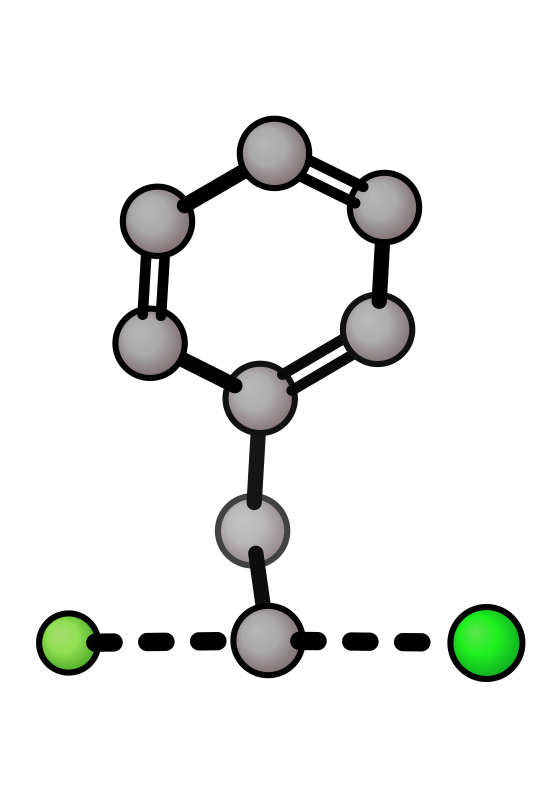

In [5]:
SN2 = ("[F-]", "[CH2]Cl", "[Cl-,Cl]")  # the reacting atoms, resolved fresh on each substrate
screen = {}
for smi in ["[F-].CCCCCl", "[F-].CC(C)CCl", "[F-].c1ccccc1CCCl"]:  # n-butyl / isobutyl / phenethyl chloride + F-
    mol = Chem.AddHs(Chem.MolFromSmiles(smi))
    f, c, cl = (mol.GetSubstructMatch(Chem.MolFromSmarts(s))[0] for s in SN2)
    ens = rx.embed(mol, fix={(f, c): 2.0, (c, cl): 2.3, (f, c, cl): 180.0}).mc(preset="rapid").prune().score("gfnff")
    screen[smi] = (ens, f, c, cl)
    dE = sorted(ens.relative().values())
    print(
        f"  {smi:22s}: {ens.n} reactive-complex conformers | GFN-FF spread {dE[-1] - dE[0]:4.1f} kcal/mol "
        f"| core d(F,C)={ens.measure((f, c))['mean']:.2f} A, angle={ens.measure((f, c, cl))['mean']:.0f} deg"
    )

ens, f, c, cl = screen["[F-].c1ccccc1CCCl"]  # the lowest reactive complex of one substrate — a DFT-ready TS guess
low = ens.lowest(1)
geom.check(low.mol, low.ids[0], frozen=[f, c, cl]).assert_ok()
xyzrender.render(low.dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, ts_bonds=[(f + 1, c + 1), (c + 1, cl + 1)])

## Why this generalises

FRUST-style embedding pins atoms with RDKit's `coordMap` — fixing them in the *embedding frame* and needing a
hardcoded bond-removal branch per reaction type. `rxembed` instead edits the **bounds matrix** (biasing the
whole distance geometry, so the core composes with metal carbon-surrogates and NCI grips) and then
**Kabsch-grafts the exact core back** to 0.000 Å. There is no per-reaction code path — a core is only ever a
set of indices plus either numbers, coordinates, or a reference geometry, fed to the same three verbs:

- **`fix={(i,j): d, (i,j,k): θ}`** — internals (§1)
- **`fix={i: (x,y,z)}`** — coordinates (§2, §3), or **`template=(reference, {i: ref_i})`** to pull them from a
  known geometry (notebook `05`)
- **`constrain={…}`** — the same, but soft (a bias a real energy may overrule)

And when you already hold a full geometry and only want it relaxed toward the core rather than
conformer-searched, `rx.minimize(source, fix=…)` is the search-free companion — same vocabulary, one geometry
in, one out.